In [59]:
import numpy as np
from tqdm import tqdm

# Helper function for Glorot uniform initialization
def glorot_uniform(shape):
    limit = np.sqrt(6 / np.sum(shape))
    return np.random.uniform(-limit, limit, shape)

class Conv2DLayer:
    def __init__(self, num_filters, kernel_size, stride=1, padding=0):
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        # Remove input_shape from initialization
        self.weights = None  # Will be initialized during the first forward pass
        self.biases = None

    def forward(self, input):
        if input.ndim == 3:  # Single image
            input = np.expand_dims(input, axis=0)  # Add batch dimension

        input = input.astype(np.float32)  # Ensure input is float
        batch_size, height, width, channels = input.shape

        # Lazy initialization of weights and biases
        if self.weights is None:
            self.input_channels = channels
            self.weights = glorot_uniform((self.num_filters, channels, self.kernel_size, self.kernel_size))
            self.biases = np.zeros((self.num_filters, 1))

        if channels != self.input_channels:
            raise ValueError(f"Expected {self.input_channels} channels but got {channels}")

        # Pad the input
        padded_input = np.pad(
            input, ((0, 0), (self.padding, self.padding), (self.padding, self.padding), (0, 0)),
            mode='constant'
        )

        self.padded_input = padded_input  # Store for backward pass
        self.input = input  # Store original input for backward pass

        # Output dimensions
        self.output_height = (height + 2 * self.padding - self.kernel_size) // self.stride + 1
        self.output_width = (width + 2 * self.padding - self.kernel_size) // self.stride + 1

        # Extract image patches
        k, s = self.kernel_size, self.stride
        shape = (batch_size, self.output_height, self.output_width, k, k, channels)
        strides = (padded_input.strides[0],
                   s * padded_input.strides[1],
                   s * padded_input.strides[2],
                   padded_input.strides[1],
                   padded_input.strides[2],
                   padded_input.strides[3])
        patches = np.lib.stride_tricks.as_strided(padded_input, shape=shape, strides=strides)
        patches = patches.reshape(batch_size * self.output_height * self.output_width, -1)

        # Reshape filters
        filters = self.weights.reshape(self.num_filters, -1).T  # Shape: (kernel_size*kernel_size*channels, num_filters)

        # Perform convolution as matrix multiplication
        output = patches @ filters + self.biases.T  # Shape: (batch_size * output_height * output_width, num_filters)
        output = output.reshape(batch_size, self.output_height, self.output_width, self.num_filters)
        self.output = output

        return output if input.ndim == 4 else output[0]  # Remove batch dimension if single image

    def backward(self, d_output, learning_rate):
        if self.input.ndim == 3:
            d_output = np.expand_dims(d_output, axis=0)

        batch_size = self.input.shape[0]
        d_output = d_output.reshape(-1, self.num_filters)

        # Gradient w.r.t. weights and biases
        patches = np.lib.stride_tricks.as_strided(
            self.padded_input,
            shape=(batch_size, self.output_height, self.output_width, self.kernel_size, self.kernel_size, self.input_channels),
            strides=(self.padded_input.strides[0],
                     self.stride * self.padded_input.strides[1],
                     self.stride * self.padded_input.strides[2],
                     self.padded_input.strides[1],
                     self.padded_input.strides[2],
                     self.padded_input.strides[3])
        ).reshape(batch_size * self.output_height * self.output_width, -1)

        d_weights = patches.T @ d_output
        d_weights = d_weights.T.reshape(self.weights.shape)
        d_biases = np.sum(d_output, axis=0, keepdims=True).T

        # Gradient w.r.t. input
        filters = self.weights.reshape(self.num_filters, -1)
        d_patches = d_output @ filters  # Shape: (batch_size * output_height * output_width, kernel_size*kernel_size*channels)
        d_patches = d_patches.reshape(batch_size, self.output_height, self.output_width, self.kernel_size, self.kernel_size, self.input_channels)

        # Initialize gradient w.r.t. padded input
        d_padded_input = np.zeros_like(self.padded_input, dtype=np.float32)
        for i in range(self.kernel_size):
            for j in range(self.kernel_size):
                d_padded_input[:, i:i + self.output_height * self.stride:self.stride,
                               j:j + self.output_width * self.stride:self.stride, :] += d_patches[:, :, :, i, j, :]

        # Remove padding to get gradient w.r.t. input
        if self.padding > 0:
            d_input = d_padded_input[:, self.padding:-self.padding, self.padding:-self.padding, :]
        else:
            d_input = d_padded_input

        # Update weights and biases
        self.weights -= learning_rate * d_weights / batch_size
        self.biases -= learning_rate * d_biases / batch_size

        return d_input if self.input.ndim == 4 else d_input[0]

class ENOSLayer:
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def forward(self, input):
        self.input = input
        if input.ndim == 3:
            input = np.expand_dims(input, axis=0)  # Add batch dimension

        mask = (input > self.threshold).astype(np.int32)
        batch_size, height, width, num_filters = input.shape

        # Compute cumulative sums for counts
        north_counts = np.cumsum(mask, axis=1) - mask
        south_counts = np.cumsum(mask[:, ::-1, :, :], axis=1)[:, ::-1, :, :] - mask
        west_counts = np.cumsum(mask, axis=2) - mask
        east_counts = np.cumsum(mask[:, :, ::-1, :], axis=2)[:, :, ::-1, :] - mask

        # Concatenate counts
        counts = np.concatenate([north_counts, south_counts, west_counts, east_counts], axis=-1)
        counts = counts.astype(np.float32)  # Convert counts to float
        self.output = counts

        return counts if self.input.ndim == 4 else counts[0]

    def backward(self, d_output, learning_rate=None):
        # Gradient w.r.t. input is zero due to non-differentiable counting operations
        return np.zeros_like(self.input, dtype=np.float32)

class MaxPoolLayer:
    # [MaxPoolLayer code remains unchanged]
    # Use the same MaxPoolLayer as before

    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride

    def forward(self, input):
        self.input = input
        if input.ndim == 3:
            input = np.expand_dims(input, axis=0)  # Add batch dimension

        batch_size, height, width, channels = input.shape
        pool_height, pool_width = self.pool_size, self.pool_size
        stride = self.stride

        out_height = (height - pool_height) // stride + 1
        out_width = (width - pool_width) // stride + 1

        # Extract pooling regions
        shape = (batch_size, out_height, out_width, pool_height, pool_width, channels)
        strides = (input.strides[0],
                   stride * input.strides[1],
                   stride * input.strides[2],
                   input.strides[1],
                   input.strides[2],
                   input.strides[3])
        patches = np.lib.stride_tricks.as_strided(input, shape=shape, strides=strides)
        patches = patches.reshape(batch_size, out_height, out_width, pool_height * pool_width, channels)

        # Transpose to bring channels to the correct position
        patches = patches.transpose(0, 1, 2, 4, 3)  # Shape: (batch_size, out_height, out_width, channels, pool_size_sq)

        # Max pooling operation
        self.output = np.max(patches, axis=4)
        self.max_indices = np.argmax(patches, axis=4)  # Shape: (batch_size, out_height, out_width, channels)

        self.patches_shape = patches.shape  # Store shape for backward pass
        return self.output if self.input.ndim == 4 else self.output[0]

    def backward(self, d_output, learning_rate=None):
        if self.input.ndim == 3:
            d_output = np.expand_dims(d_output, axis=0)

        batch_size, out_height, out_width, channels = d_output.shape
        pool_size_sq = self.pool_size * self.pool_size

        # Initialize gradient tensor
        d_patches = np.zeros((batch_size, out_height, out_width, channels, pool_size_sq), dtype=np.float32)

        # Flatten the indices for easy assignment
        d_output_flat = d_output.transpose(0, 3, 1, 2).reshape(-1)
        max_indices_flat = self.max_indices.transpose(0, 3, 1, 2).flatten()

        # Compute indices for assignment
        indices = np.arange(d_output_flat.size)

        # Assign gradients to the correct positions
        d_patches_flat = d_patches.reshape(-1, pool_size_sq)
        np.add.at(d_patches_flat, (indices, max_indices_flat), d_output_flat)

        # Reshape d_patches back to original shape
        d_patches = d_patches.reshape(batch_size, out_height, out_width, channels, pool_size_sq)
        d_patches = d_patches.transpose(0, 1, 2, 4, 3)
        d_patches = d_patches.reshape(batch_size, out_height, out_width, self.pool_size, self.pool_size, channels)

        # Initialize d_input
        d_input = np.zeros_like(self.input, dtype=np.float32)

        # Sum gradients into d_input
        for i in range(self.pool_size):
            for j in range(self.pool_size):
                d_input[:, i:i + out_height * self.stride:self.stride,
                        j:j + out_width * self.stride:self.stride, :] += d_patches[:, :, :, i, j, :]

        return d_input if self.input.ndim == 4 else d_input[0]


class ReLU:
    def forward(self, input):
        self.input = input
        self.output = np.maximum(0, input)
        return self.output

    def backward(self, d_output, learning_rate=None):
        return d_output * (self.input > 0).astype(np.float32)

    
class LeakyReLU:
    def __init__(self, alpha=0.01):
        self.alpha = alpha

    def forward(self, input):
        self.input = input
        self.output = np.where(input > 0, input, self.alpha * input)
        return self.output

    def backward(self, d_output, learning_rate=None):
        dx = np.ones_like(self.input)
        dx[self.input < 0] = self.alpha
        return d_output * dx

class Sigmoid:
    def forward(self, input):
        self.input = input
        self.output = 1 / (1 + np.exp(-input))
        return self.output

    def backward(self, d_output, learning_rate=None):
        return d_output * self.output * (1 - self.output)

class Softmax:
    def forward(self, input):
        self.input = input
        exps = np.exp(input - np.max(input, axis=1, keepdims=True))
        self.output = exps / np.sum(exps, axis=1, keepdims=True)
        return self.output

    def backward(self, d_output, learning_rate=None):
        # Gradient will be computed in compute_loss
        return d_output

class LogActivation:
    def forward(self, input):
        self.input = np.clip(input, 1e-10, None)
        self.output = np.log(self.input)
        return self.output

    def backward(self, d_output, learning_rate=None):
        return d_output / self.input

class Tanh:
    def forward(self, input):
        self.input = input
        self.output = np.tanh(input)
        return self.output

    def backward(self, d_output, learning_rate=None):
        return d_output * (1 - self.output ** 2)

class NeuralNet:
    def __init__(self):
        self.layers = []
        self.loss_history = []

    def save(self, file_path):
        params = {}
        for i, layer in enumerate(self.layers):
            if hasattr(layer, 'weights') and hasattr(layer, 'biases'):
                params[f'layer_{i}_weights'] = layer.weights
                params[f'layer_{i}_biases'] = layer.biases
        np.savez(file_path, **params)
        print(f"Model saved to {file_path}")

    def load(self, file_path):
        data = np.load(file_path)
        for i, layer in enumerate(self.layers):
            if hasattr(layer, 'weights') and hasattr(layer, 'biases'):
                layer.weights = data[f'layer_{i}_weights']
                layer.biases = data[f'layer_{i}_biases']
        print(f"Model loaded from {file_path}")

    def add(self, layer):
        self.layers.append(layer)

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, d_output, learning_rate):
        for layer in reversed(self.layers):
            d_output = layer.backward(d_output, learning_rate)

    def compute_loss(self, y_pred, y_true):
        m = y_true.shape[0]
        loss = -np.sum(y_true * np.log(y_pred + 1e-15)) / m
        d_loss = (y_pred - y_true) / m
        return loss, d_loss

    def train(self, X_train, y_train, epochs, learning_rate, batch_size=32):
        n_samples = X_train.shape[0]
        for epoch in range(epochs):
            epoch_loss = 0
            for i in tqdm(range(0, n_samples, batch_size)):
                X_batch = X_train[i:i + batch_size]
                y_batch = y_train[i:i + batch_size]

                # Forward pass
                y_pred = self.forward(X_batch)

                # Loss computation
                loss, d_loss = self.compute_loss(y_pred, y_batch)
                epoch_loss += loss

                # Backward pass
                self.backward(d_loss, learning_rate)

            # Average loss for the epoch
            epoch_loss /= (n_samples // batch_size)
            self.loss_history.append(epoch_loss)
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")

    def predict(self, X):
        return self.forward(X)

class FlattenLayer:
    def forward(self, input):
        self.input_shape = input.shape
        return input.reshape(self.input_shape[0], -1)

    def backward(self, d_output, learning_rate=None):
        return d_output.reshape(self.input_shape)

class DenseLayer:
    def __init__(self, output_dim):
        self.output_dim = output_dim
        self.weights = None  # Will be initialized during the first forward pass
        self.biases = None

    def forward(self, input):
        if self.weights is None:
            input_dim = input.shape[1]
            self.weights = glorot_uniform((input_dim, self.output_dim))
            self.biases = np.zeros((1, self.output_dim))
        self.input = input
        return np.dot(input, self.weights) + self.biases

    def backward(self, d_output, learning_rate):
        d_weights = np.dot(self.input.T, d_output)
        d_biases = np.sum(d_output, axis=0, keepdims=True)
        d_input = np.dot(d_output, self.weights.T)

        # Update parameters
        self.weights -= learning_rate * d_weights / self.input.shape[0]
        self.biases -= learning_rate * d_biases / self.input.shape[0]
        return d_input

# def build_model(input_shape):
#     model = NeuralNet()
#     model.add(ENOSLayer(threshold=0.5))
#     model.add(Conv2DLayer(num_filters=8, kernel_size=3, stride=1, padding=1))
#     model.add(ReLU())
#     model.add(MaxPoolLayer(pool_size=2, stride=2))
#     model.add(ENOSLayer(threshold=0.5))
#     model.add(Conv2DLayer(num_filters=16, kernel_size=3, stride=1, padding=1))
#     model.add(ReLU())
#     model.add(MaxPoolLayer(pool_size=2, stride=2))
#     model.add(FlattenLayer())
#     model.add(DenseLayer(output_dim=10))
#     model.add(Softmax())
#     return model

def build_model(input_shape):
    model = NeuralNet()
    model.add(ENOSLayer(threshold=0.5))
    model.add(Conv2DLayer(num_filters=8, kernel_size = 3, stride = 1, padding = 2))
    model.add(ReLU())
    model.add(MaxPoolLayer(pool_size=2, stride=2))
    model.add(Conv2DLayer(num_filters=8, kernel_size = 3, stride = 1, padding = 2))
    model.add(Tanh())
    model.add(MaxPoolLayer(pool_size=2, stride=2))
    model.add(Conv2DLayer(num_filters=8, kernel_size = 3, stride = 1, padding = 2))
    model.add(Tanh())
    model.add(FlattenLayer())
    model.add(DenseLayer(output_dim=10))
    model.add(Softmax())
    return model

def load_mnist_data(x=None):
    from tensorflow.keras.datasets import mnist
    from tensorflow.keras.utils import to_categorical
    (X_train, y_train_labels), (X_test, y_test_labels) = mnist.load_data()
    
    if x is not None:
        X_train, y_train_labels = X_train[:x], y_train_labels[:x]
        X_test, y_test_labels = X_test[:x], y_test_labels[:x]
        
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0
    
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    y_train = to_categorical(y_train_labels, num_classes=10)
    y_test = to_categorical(y_test_labels, num_classes=10)
    
    return X_train, y_train, X_test, y_test



In [62]:
# Build and train the model
X_train, y_train, X_test, y_test = load_mnist_data()
model = build_model(input_shape=(28, 28, 1))
model.train(X_train, y_train, epochs=50, learning_rate=0.05, batch_size=16)

# Predict and evaluate
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)
accuracy = np.mean(predicted_classes == true_classes)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

100%|██████████| 3750/3750 [01:13<00:00, 51.37it/s]


Epoch 1/50, Loss: 0.8388


100%|██████████| 3750/3750 [01:12<00:00, 51.95it/s]


Epoch 2/50, Loss: 0.6110


100%|██████████| 3750/3750 [01:18<00:00, 47.76it/s]


...

Epoch 38/50, Loss: 0.5591


100%|██████████| 3750/3750 [35:41<00:00,  1.75it/s]  


Epoch 39/50, Loss: 0.5824


 12%|█▏        | 435/3750 [09:15<1:10:33,  1.28s/it] 


KeyboardInterrupt: 

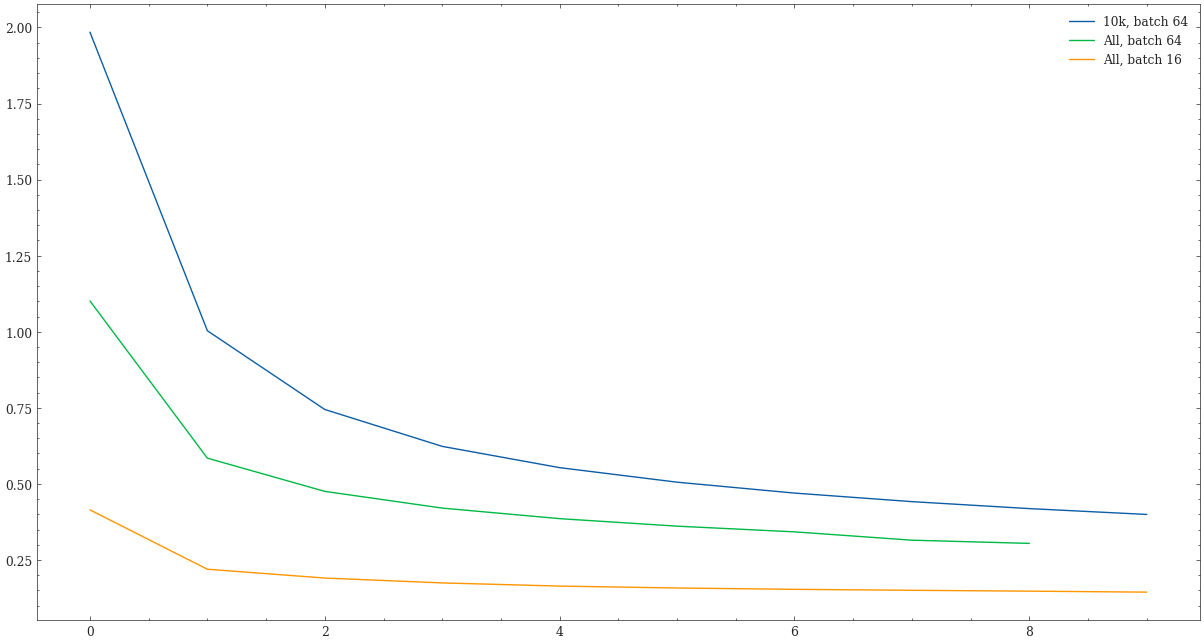

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots

plt.style.use('science') 
plt.rcParams['text.usetex'] = False
plt.figure(figsize=(15,8))

training_10k_batch64 = [1.9846,1.0034,0.7446,0.6234,0.5535,0.5057,0.4699,0.4418,0.4189,0.3997]
training_all_batch64 = [1.1013,0.5847,0.4755,0.4206,0.3859,0.3612, 0.3425, 0.3151, 0.3046]
training_all_batch16 = [0.4147,0.2197,0.1907,0.1747,0.1643, 0.1580,0.1536,0.1505,0.1476,0.1444]


plt.plot(training_10k_batch64, label = '10k, batch 64')
plt.plot(training_all_batch64, label = 'All, batch 64')
plt.plot(training_all_batch16, label = 'All, batch 16')
plt.legend()
plt.show()


In [60]:
model.save('model_all_(batch16).npz')

Model saved to model_all_(batch16).npz


In [30]:
model = build_model(input_shape=(28, 28, 1))
model.load("/Users/conorosiadhail/Documents/ENOS:CNN/models/model_all_(batch16).npz")


Model loaded from /Users/conorosiadhail/Documents/ENOS:CNN/models/model_all_(batch16).npz


First image shape: (28, 28, 1)
First image label: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


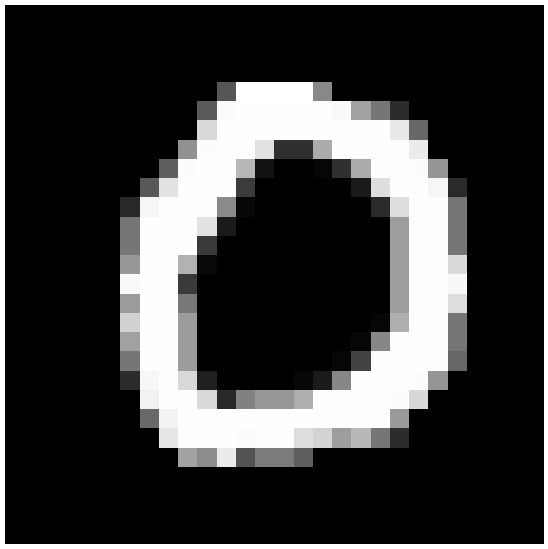

In [35]:
# Load only the first image from the dataset
X_train, y_train, X_test, y_test = load_mnist_data(200)

# Access the first image and its label
n_image = 71
image = X_test[n_image]
label = y_test[n_image]

print("First image shape:", image.shape)
print("First image label:", label)

plt.figure(figsize=(7,7))
plt.axis('off')
plt.imshow(image,cmap='gray')



In [36]:
probabilities = model.predict(image)

percentages = probabilities * 100

print(f'Model Prediction: {np.argmax(probabilities)}, with {((np.max(probabilities))*100):.2f}% probability')

# Display with digit labels
for digit, prob in enumerate(percentages[0]):
    print(f"{digit}: {prob:.2f}%", end = '   ')
    



Model Prediction: 0, with 100.00% probability
0: 100.00%   1: 0.00%   2: 0.00%   3: 0.00%   4: 0.00%   5: 0.00%   6: 0.00%   7: 0.00%   8: 0.00%   9: 0.00%   